Loading data from D:/Research/Embryo_video/260115_video.csv...
--------------------------------------------------
X Variable      | Y Variable      | Pearson r  | P-value
--------------------------------------------------
Diameter        | Velocity_Abs    | 0.2585     | 4.0357e-03
Area            | Velocity_Abs    | 0.2697     | 2.6596e-03
Diameter        | Velocity_X      | 0.2241     | 1.3090e-02
Area            | Velocity_X      | 0.2258     | 1.2392e-02
--------------------------------------------------
Figure saved to: D:/Research/Embryo_video\nature_style_analysis_4panel.svg


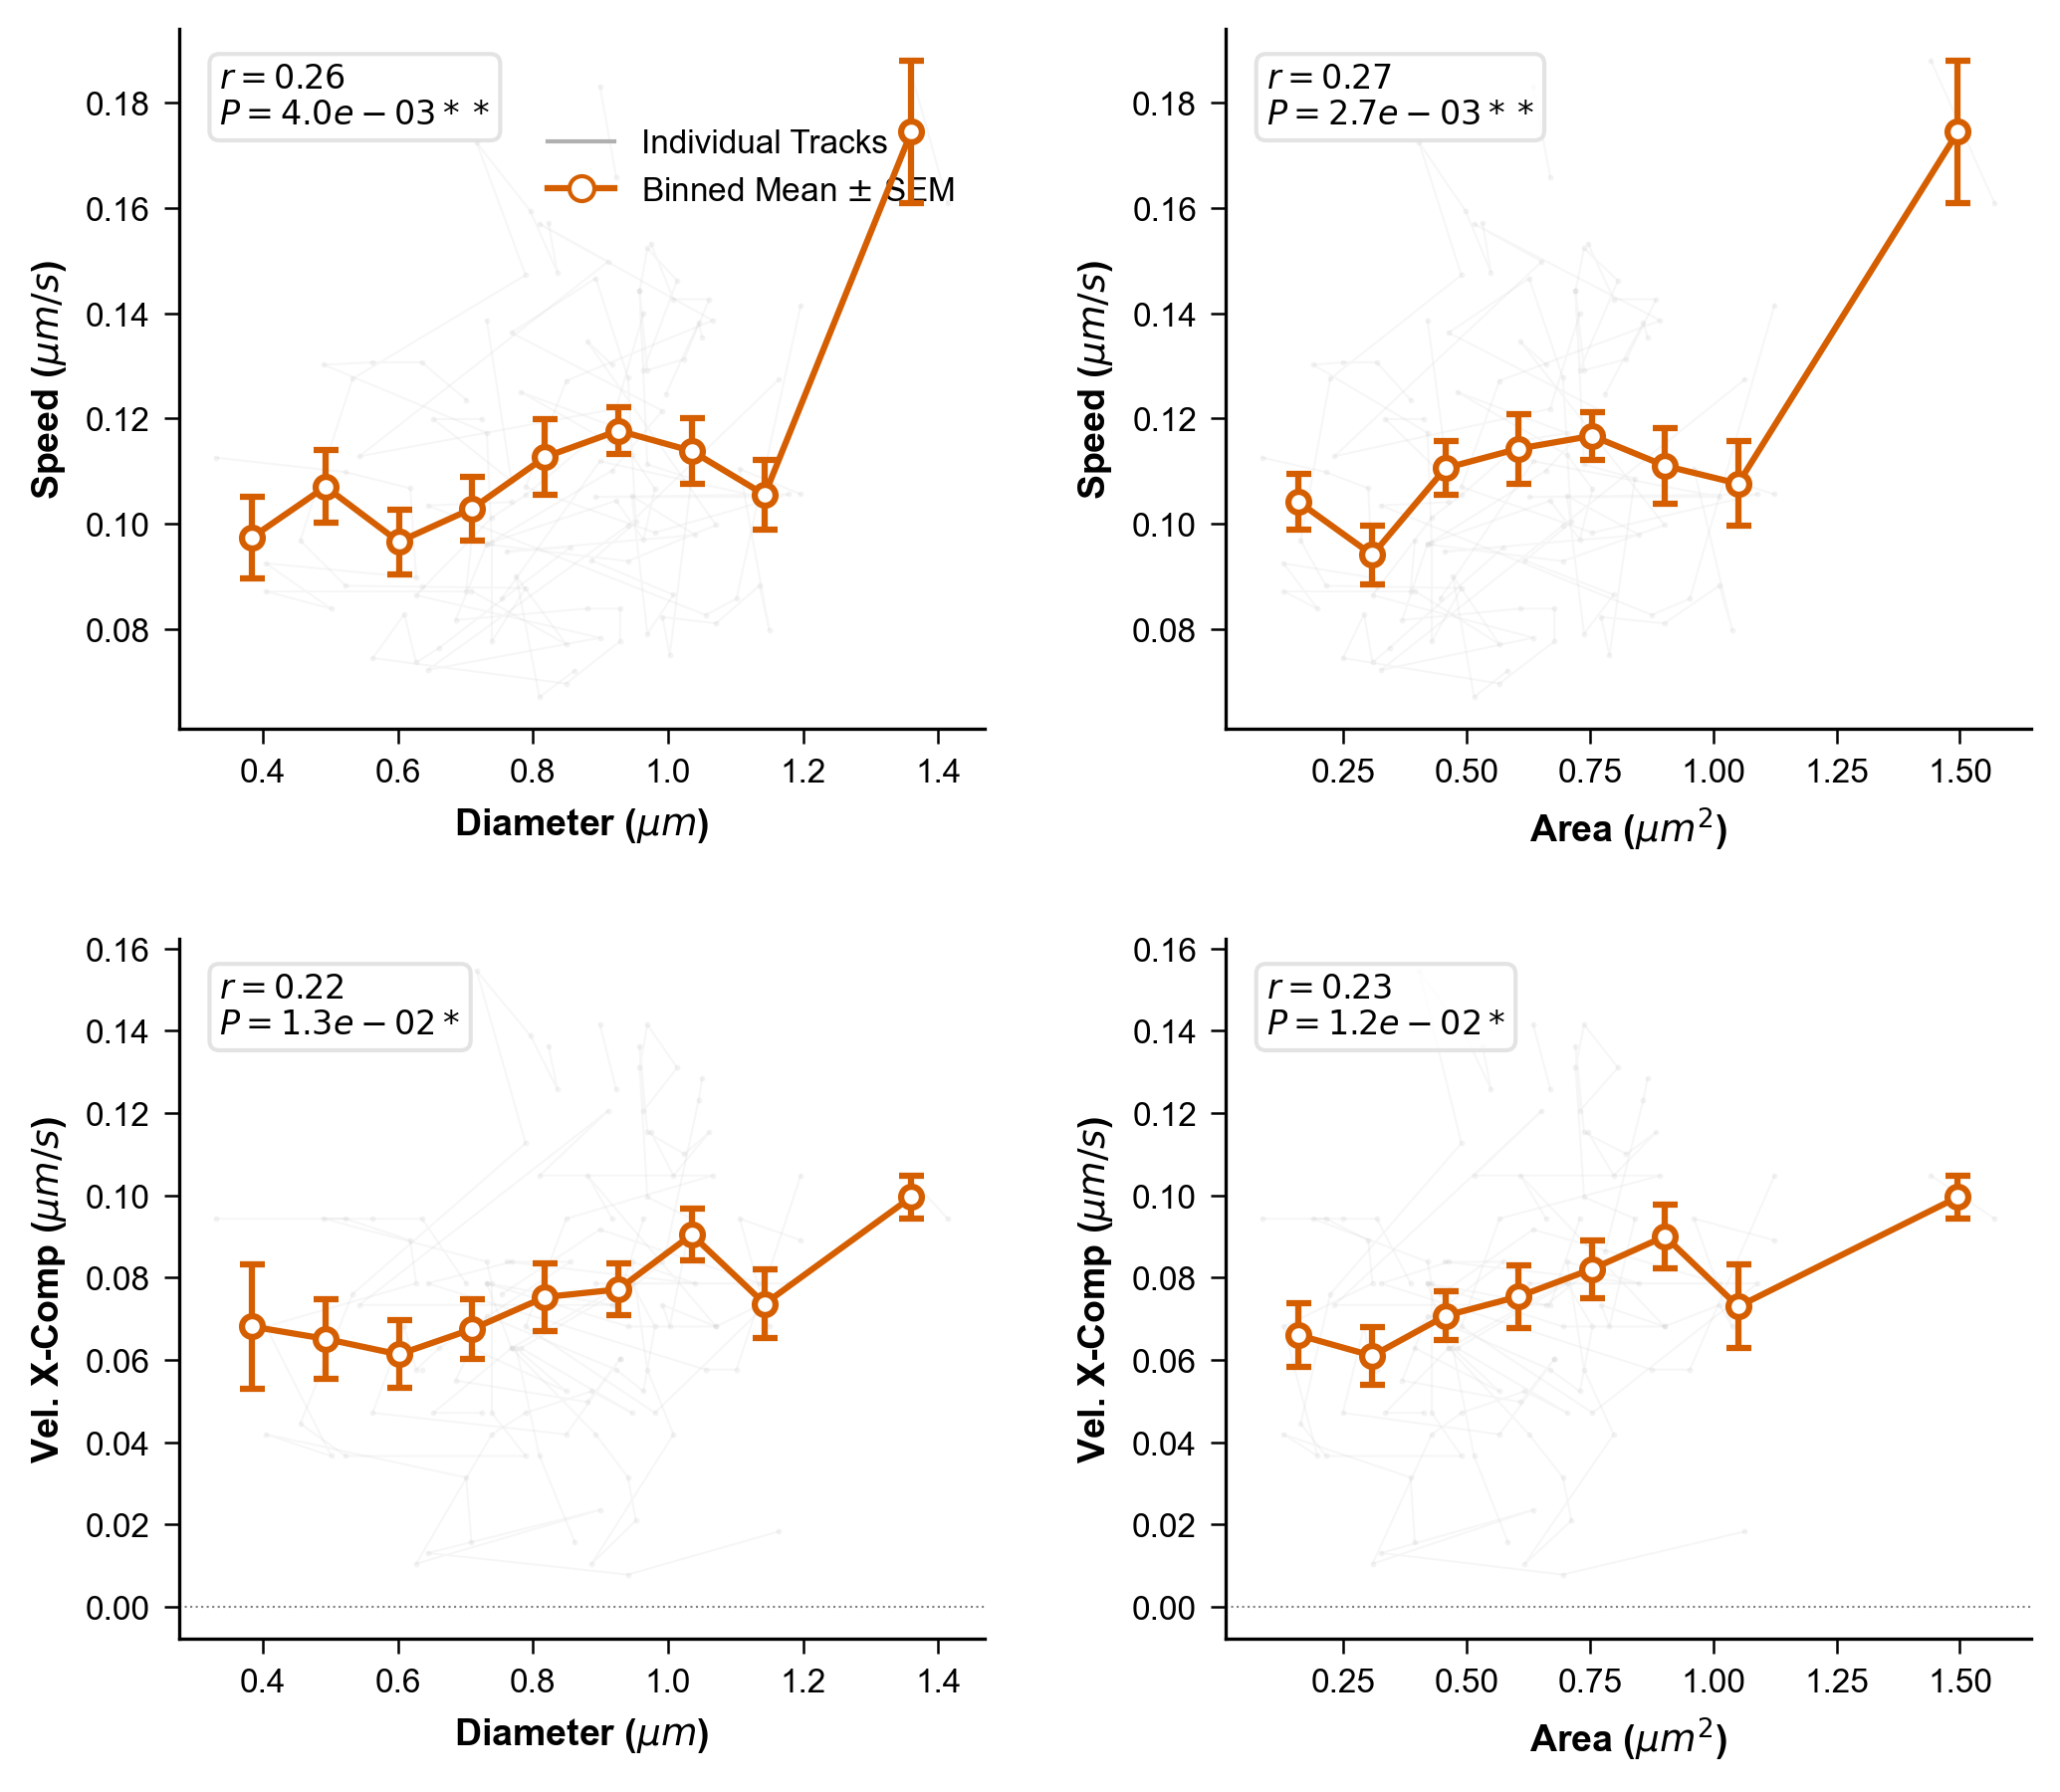

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import os

# ==========================================
# 1. Plot Configuration (minimal Nature/Science style)
# ==========================================
def set_nature_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['font.size'] = 8          # Smaller font for a refined look
    plt.rcParams['axes.labelsize'] = 9
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['axes.linewidth'] = 0.8   # Ultra-thin spines
    plt.rcParams['xtick.major.width'] = 0.6
    plt.rcParams['ytick.major.width'] = 0.6
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.bbox'] = 'tight'

# ==========================================
# 2. Data Processing: add smoothing and binning logic
# ==========================================
def process_data_robust(df, smooth_window=3):
    """
    处理数据，加入滑动平均以减少噪声。
    """
    processed_rows = []
    grouped = df.groupby('TRACK_ID')
    
    for track_id, group in grouped:
        # Sort by time
        g = group.sort_values('POSITION_T').reset_index(drop=True)
        
        # === Core improvement: calculate raw velocity first, then smooth ===
        # Calculate displacement differences (dX, dY) and time differences (dT)
        d_pos = g[['POSITION_X', 'POSITION_Y']].diff()
        dt = g['POSITION_T'].diff()
        
        # Calculate instantaneous velocity (raw)
        # Note: the first row after diff is NaN and needs to be handled
        v_x = d_pos['POSITION_X'] / dt
        v_y = d_pos['POSITION_Y'] / dt
        v_abs = np.sqrt(v_x**2 + v_y**2)
        
        # === Smoothing ===
        # Use a rolling mean to reduce jagged noise
        if smooth_window > 1:
            v_x = v_x.rolling(window=smooth_window, center=True).mean()
            v_abs = v_abs.rolling(window=smooth_window, center=True).mean()
        
        # Corresponding X-axis attribute (mean of the sliding-window center, or current value directly)
        # For alignment, use the corresponding row from the raw data
        
        # Reassemble data
        temp_df = pd.DataFrame({
            'TRACK_ID': track_id,
            'Time': g['POSITION_T'],
            'Diameter': g['DIAMETER'],
            'Area': g['AREA'],
            'Velocity_Abs': v_abs,
            'Velocity_X': v_x
        })
        
        # Remove NaNs introduced by diff and rolling
        temp_df = temp_df.dropna()
        processed_rows.append(temp_df)
            
    return pd.concat(processed_rows)

def calculate_binned_stats(df, x_col, y_col, bins=8):
    """
    核心统计算法：将X轴切分为若干区间，计算每个区间内Y的均值和标准误
    """
    # Create bins
    df['bin'] = pd.cut(df[x_col], bins=bins)
    
    # Aggregate
    stats = df.groupby('bin', observed=True)[y_col].agg(['mean', 'sem', 'count']).reset_index()
    
    # Use the center of each bin as the plotting X coordinate
    stats['x_center'] = stats['bin'].apply(lambda x: x.mid).astype(float)
    
    return stats.dropna()

# ==========================================
# 3. Simulated Data Generation (with noise)
# ==========================================
def generate_noisy_data():
    np.random.seed(123)
    data = []
    n_tracks = 18
    for tid in range(1, n_tracks+1):
        t = np.arange(0, 30, 0.5) # 60 frames
        # Assumption: larger particles move more slowly (negative correlation)
        base_dia = np.random.uniform(1.5, 4.5) 
        
        # Simulate diameter variation
        dia = base_dia + np.random.normal(0, 0.1, len(t))
        area = np.pi * (dia/2)**2
        
        # Simulate velocity (with noise)
        # True velocity + random noise
        true_v = 2.0 / dia # Simple inverse relationship
        noise = np.random.normal(0, 0.5, len(t))
        
        # Integrate to obtain positions (to simulate real tracking data)
        v_inst = true_v + noise
        x = np.cumsum(v_inst * 0.5) 
        y = np.random.normal(0, 1, len(t))
        
        for i in range(len(t)):
            data.append([tid, t[i], x[i], y[i], dia[i], area[i]])
            
    return pd.DataFrame(data, columns=['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y', 'DIAMETER', 'AREA'])

# ==========================================
# 4. Core Plotting: background spaghetti lines + foreground statistical lines + correlation analysis
# ==========================================
def plot_hybrid_analysis(df, save_dir='.'):
    set_nature_style()
    
    # Define four panels (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(8, 7)) # Width 8 inches, height 7 inches
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
    # Configuration list
    configs = [
        # Row 1: Velocity Magnitude
        {'x': 'Diameter', 'y': 'Velocity_Abs', 'ax': axes[0, 0], 
         'xlab': 'Diameter ($\mu m$)', 'ylab': 'Speed ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_Abs', 'ax': axes[0, 1], 
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Speed ($\mu m/s$)'},
        
        # Row 2: Velocity X Component
        {'x': 'Diameter', 'y': 'Velocity_X', 'ax': axes[1, 0], 
         'xlab': 'Diameter ($\mu m$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_X', 'ax': axes[1, 1], 
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'}
    ]
    
    # Colors
    raw_color = '#B0B0B0'  # Light gray for raw trajectories
    stat_color = '#D55E00' # Vermilion
    
    print("-" * 50)
    print(f"{'X Variable':<15} | {'Y Variable':<15} | {'Pearson r':<10} | {'P-value'}")
    print("-" * 50)

    for cfg in configs:
        ax = cfg['ax']
        x_col = cfg['x']
        y_col = cfg['y']
        
        # --- Pearson Correlation ---
        # Calculate correlation for the full dataset
        clean_data = df[[x_col, y_col]].dropna()
        r, p = pearsonr(clean_data[x_col], clean_data[y_col])
        
        # Print to console
        print(f"{x_col:<15} | {y_col:<15} | {r:.4f}     | {p:.4e}")
        
        # Display the correlation coefficient in the plot
        # Show asterisks based on the P-value
        stars = ''
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stats_text = f"$r = {r:.2f}$\n$P = {p:.1e}{stars}$"
        # Place in the upper-left corner (transform=ax.transAxes uses relative coordinates)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#dddddd'))

        # --- Layer 1: Raw Trajectories (Raw Spaghetti) ---
        for tid in df['TRACK_ID'].unique():
            sub = df[df['TRACK_ID'] == tid]
            # To avoid cluttered lines in the phase map, draw only faint lines or just scatter points
            # The logic here is: connect points in time order to show trajectory movement in phase space
            sub_by_time = sub.sort_values('Time')
            
            ax.plot(sub_by_time[x_col], sub_by_time[y_col], 
                    color=raw_color, alpha=0.1, linewidth=0.5, linestyle='-', zorder=1)
            
            ax.scatter(sub[x_col], sub[y_col], color=raw_color, s=2, alpha=0.15, linewidth=0, zorder=1)

        # --- Layer 2: Binned Statistical Trend (Binned Statistics) ---
        stats = calculate_binned_stats(df, x_col, y_col, bins=10)
        
        ax.errorbar(stats['x_center'], stats['mean'], yerr=stats['sem'], 
                    fmt='-o',             
                    color=stat_color, 
                    linewidth=1.5,        
                    capsize=3,            
                    markersize=5,
                    markerfacecolor='white',
                    markeredgewidth=1.5,
                    zorder=10)            
        
        # --- Decorations ---
        ax.set_xlabel(cfg['xlab'], fontweight='bold')
        ax.set_ylabel(cfg['ylab'], fontweight='bold')
            
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # X-direction velocity may be positive or negative; add a zero reference line
        if 'Velocity_X' in y_col:
            ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.5, zorder=0)

    # Unified legend (placed in the first plot)
    legend_elements = [
        Line2D([0], [0], color=raw_color, lw=1, label='Individual Tracks'),
        Line2D([0], [0], color=stat_color, lw=1.5, marker='o', markerfacecolor='white', label='Binned Mean $\pm$ SEM')
    ]
    axes[0, 0].legend(handles=legend_elements, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 0.9))

    # Save
    save_path = os.path.join(save_dir, 'nature_style_analysis_4panel.svg')
    plt.savefig(save_path, format='svg')
    print("-" * 50)
    print(f"Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    # Configure input file path
    input_file = 'D:/Research/Embryo_video/260115_video.csv'
    
    # Automatically obtain the directory
    file_dir = os.path.dirname(input_file)
    if not file_dir: file_dir = '.' # If the path is empty, default to the current directory
    
    if os.path.exists(input_file):
        print(f"Loading data from {input_file}...")
        raw = pd.read_csv(input_file)
        
        # Process data (smoothing window = 5)
        processed = process_data_robust(raw, smooth_window=5)
        
        # Plot (save results to the same directory)
        plot_hybrid_analysis(processed, save_dir=file_dir)
        
    else:
        print(f"Warning: File {input_file} not found. Using generated mock data.")
        raw = generate_noisy_data()
        processed = process_data_robust(raw, smooth_window=5)
        plot_hybrid_analysis(processed, save_dir='.')

Loading data from D:/Research/Embryo_video/260115_video.csv...
-----------------------------------------------------------------
X Variable      | Y Variable      | Pearson r  | P-value    | N(Total)
-----------------------------------------------------------------
Radius          | Velocity_X      | 0.2241     | 1.3090e-02 | 122
Area            | Velocity_X      | 0.2258     | 1.2392e-02 | 122
-----------------------------------------------------------------
Figure saved to: D:/Research/Embryo_video\nature_style_velocity_X_analysis.svg


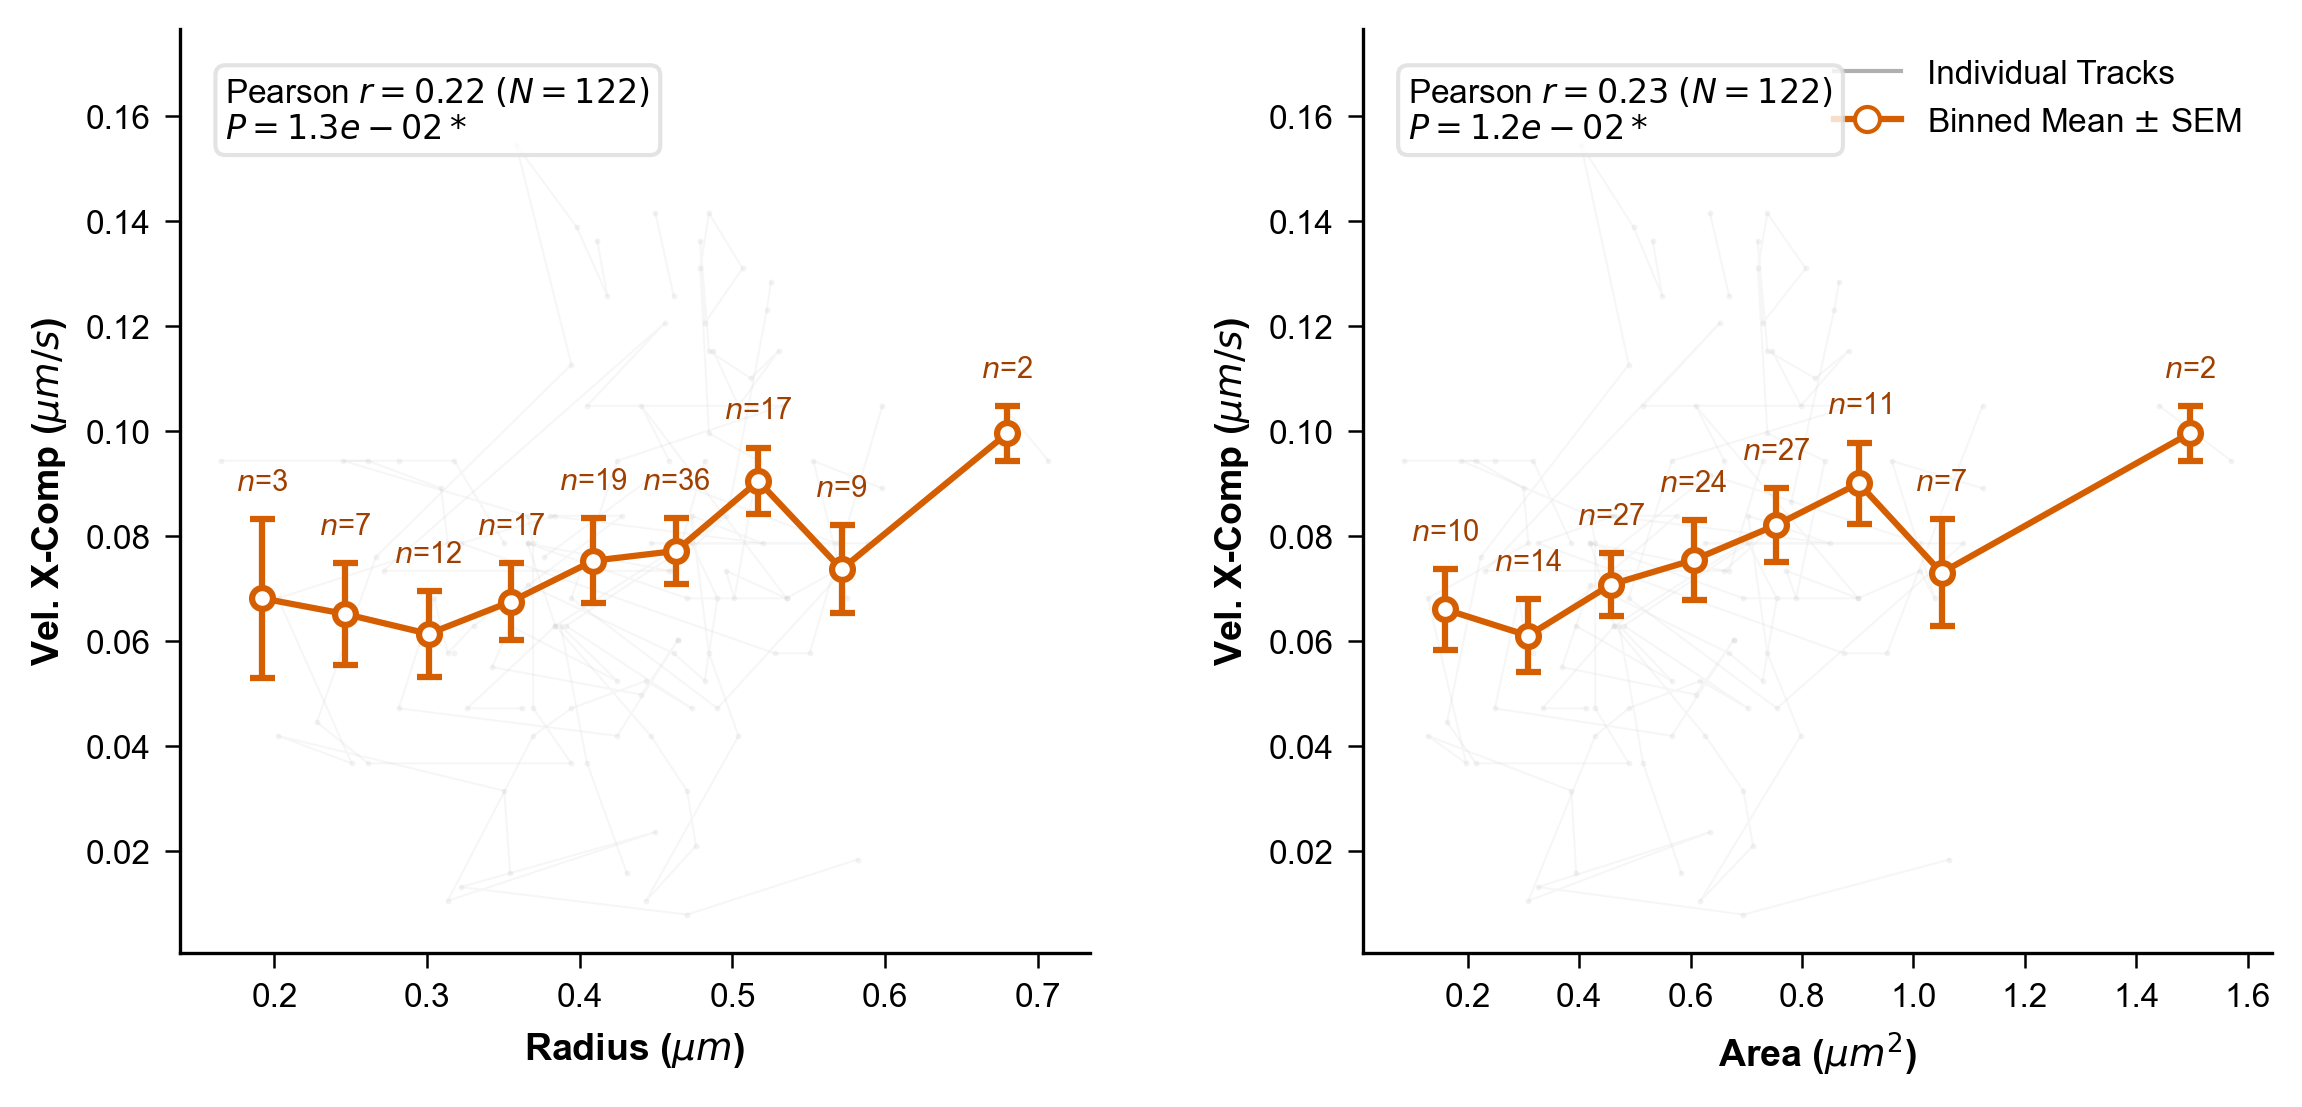

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import os

# ==========================================
# 1. Plot Configuration (minimal Nature/Science style)
# ==========================================
def set_nature_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['font.size'] = 8          # Smaller font for a refined look
    plt.rcParams['axes.labelsize'] = 9
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['axes.linewidth'] = 0.8   # Ultra-thin spines
    plt.rcParams['xtick.major.width'] = 0.6
    plt.rcParams['ytick.major.width'] = 0.6
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.bbox'] = 'tight'

# ==========================================
# 2. Data Processing: add smoothing and binning logic, calculate radius
# ==========================================
def process_data_robust(df, smooth_window=3):
    """
    处理数据，加入滑动平均以减少噪声，并计算半径。
    """
    processed_rows = []
    grouped = df.groupby('TRACK_ID')
    
    for track_id, group in grouped:
        # Sort by time
        g = group.sort_values('POSITION_T').reset_index(drop=True)
        
        # Calculate displacement differences (dX) and time differences (dT)
        d_pos_x = g['POSITION_X'].diff()
        dt = g['POSITION_T'].diff()
        
        # Calculate instantaneous X-direction velocity (raw)
        v_x = d_pos_x / dt
        
        # === Smoothing ===
        if smooth_window > 1:
            v_x = v_x.rolling(window=smooth_window, center=True).mean()
        
        # Reassemble data (convert diameter to radius)
        temp_df = pd.DataFrame({
            'TRACK_ID': track_id,
            'Time': g['POSITION_T'],
            'Radius': g['DIAMETER'] / 2.0,  # Improvement 1: calculate radius
            'Area': g['AREA'],
            'Velocity_X': v_x               # Improvement 3: keep only X-direction velocity
        })
        
        # Remove NaNs introduced by diff and rolling
        temp_df = temp_df.dropna()
        processed_rows.append(temp_df)
            
    return pd.concat(processed_rows)

def calculate_binned_stats(df, x_col, y_col, bins=8):
    """
    核心统计算法：将X轴切分为若干区间，计算每个区间内Y的均值(mean)、标准误(sem)和样本量(count)
    """
    # Create bins
    df['bin'] = pd.cut(df[x_col], bins=bins)
    
    # Aggregate
    stats = df.groupby('bin', observed=True)[y_col].agg(['mean', 'sem', 'count']).reset_index()
    
    # Use the center of each bin as the plotting X coordinate
    stats['x_center'] = stats['bin'].apply(lambda x: x.mid).astype(float)
    
    return stats.dropna()

# ==========================================
# 3. Simulated Data Generation (with noise)
# ==========================================
def generate_noisy_data():
    np.random.seed(123)
    data = []
    n_tracks = 18
    for tid in range(1, n_tracks+1):
        t = np.arange(0, 30, 0.5) # 60 frames
        base_dia = np.random.uniform(1.5, 4.5) 
        
        # Simulate diameter variation
        dia = base_dia + np.random.normal(0, 0.1, len(t))
        area = np.pi * (dia/2)**2
        
        # Simulate velocity (with noise)
        true_v = 2.0 / dia 
        noise = np.random.normal(0, 0.5, len(t))
        
        # Integrate to obtain positions
        v_inst = true_v + noise
        x = np.cumsum(v_inst * 0.5) 
        y = np.random.normal(0, 1, len(t))
        
        for i in range(len(t)):
            data.append([tid, t[i], x[i], y[i], dia[i], area[i]])
            
    return pd.DataFrame(data, columns=['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y', 'DIAMETER', 'AREA'])

# ==========================================
# 4. Core Plotting: plot only Velocity_X and annotate N
# ==========================================
def plot_hybrid_analysis(df, save_dir='.'):
    set_nature_style()
    
    # Define two panels (1x2) - Improvement 3
    fig, axes = plt.subplots(1, 2, figsize=(9, 4)) 
    plt.subplots_adjust(wspace=0.3)
    
    # Configuration list
    configs = [
        {'x': 'Radius', 'y': 'Velocity_X', 'ax': axes[0], 
         'xlab': 'Radius ($\mu m$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_X', 'ax': axes[1], 
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'}
    ]
    
    raw_color = '#B0B0B0'  # Light gray
    stat_color = '#D55E00' # Vermilion
    text_color = '#A04000' # Darker vermilion for N annotations
    
    print("-" * 65)
    print(f"{'X Variable':<15} | {'Y Variable':<15} | {'Pearson r':<10} | {'P-value':<10} | {'N(Total)'}")
    print("-" * 65)

    for cfg in configs:
        ax = cfg['ax']
        x_col = cfg['x']
        y_col = cfg['y']
        
        # --- Calculate Pearson Correlation and Total N ---
        clean_data = df[[x_col, y_col]].dropna()
        n_total = len(clean_data) # Improvement 2: calculate total N
        r, p = pearsonr(clean_data[x_col], clean_data[y_col])
        
        print(f"{x_col:<15} | {y_col:<15} | {r:.4f}     | {p:.4e} | {n_total}")
        
        # Show asterisks based on the P-value
        stars = ''
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        # Improvement 2: explicitly identify Pearson r and add (N=xxx)
        stats_text = f"Pearson $r = {r:.2f}$ $(N={n_total})$\n$P = {p:.1e}{stars}$"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#dddddd'),
                zorder=20)

        # --- Layer 1: Raw Trajectories ---
        for tid in df['TRACK_ID'].unique():
            sub = df[df['TRACK_ID'] == tid]
            sub_by_time = sub.sort_values('Time')
            ax.plot(sub_by_time[x_col], sub_by_time[y_col], 
                    color=raw_color, alpha=0.1, linewidth=0.5, linestyle='-', zorder=1)
            ax.scatter(sub[x_col], sub[y_col], color=raw_color, s=2, alpha=0.15, linewidth=0, zorder=1)

        # --- Layer 2: Binned Statistical Trend (Mean +/- SEM) ---
        stats = calculate_binned_stats(df, x_col, y_col, bins=10)
        
        ax.errorbar(stats['x_center'], stats['mean'], yerr=stats['sem'], 
                    fmt='-o', color=stat_color, linewidth=1.5, capsize=3, markersize=5,
                    markerfacecolor='white', markeredgewidth=1.5, zorder=10)            
        
        # Improvement 2: annotate the corresponding sample size N for each bin's error bar
        y_span = df[y_col].max() - df[y_col].min()
        offset = y_span * 0.03 # Dynamically calculate text offset to prevent overlap with data points
        
        for _, row in stats.iterrows():
            # Write N above the error bars
            text_y = row['mean'] + (row['sem'] if not np.isnan(row['sem']) else 0) + offset
            ax.text(row['x_center'], text_y, f"$n$={int(row['count'])}", 
                    ha='center', va='bottom', fontsize=7, color=text_color, zorder=15)

        # --- Decoration and Layout ---
        ax.set_xlabel(cfg['xlab'], fontweight='bold')
        ax.set_ylabel(cfg['ylab'], fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Expand space above the Y-axis to prevent N text from being clipped by the top edge
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] + y_span * 0.1)
        
        # Add a horizontal reference line at 0
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.5, zorder=0)

    # Unified legend
    legend_elements = [
        Line2D([0], [0], color=raw_color, lw=1, label='Individual Tracks'),
        Line2D([0], [0], color=stat_color, lw=1.5, marker='o', markerfacecolor='white', label='Binned Mean $\pm$ SEM')
    ]
    axes[1].legend(handles=legend_elements, frameon=False, loc='upper right')

    # Save
    save_path = os.path.join(save_dir, 'nature_style_velocity_X_analysis.svg')
    plt.savefig(save_path, format='svg')
    print("-" * 65)
    print(f"Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    # Configure input file path
    input_file = 'D:/Research/Embryo_video/260115_video.csv'
    
    file_dir = os.path.dirname(input_file)
    if not file_dir: file_dir = '.' 
    
    if os.path.exists(input_file):
        print(f"Loading data from {input_file}...")
        raw = pd.read_csv(input_file)
        
        processed = process_data_robust(raw, smooth_window=5)
        plot_hybrid_analysis(processed, save_dir=file_dir)
        
    else:
        print(f"Warning: File {input_file} not found. Using generated mock data.")
        raw = generate_noisy_data()
        processed = process_data_robust(raw, smooth_window=5)
        plot_hybrid_analysis(processed, save_dir='.')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import os

# ==========================================
# 0. Global Configuration (centralize all model/plotting/processing parameters)
# ==========================================
class Config:
    # --- Input/Output ---
    INPUT_FILE = 'D:\\Research\\Embryo_video\\260115_video.csv'
    SAVE_FILENAME = 'nature_style_velocity_X_analysis_ygb.svg'

    # --- Data Processing ---
    SMOOTH_WINDOW = 5
    BIN_COUNT = 10

    # --- YGB Theoretical Model Parameters ---
    XI_NM = 25               # Pore permeability coefficient (nm)
    ETA_SOL = 0.01           # Base solvent viscosity (Pa*s)

    # Theoretical band parameter range (upper/lower bounds for fill_between)
    THEORY_ETA_IN_MIN = 2.5
    THEORY_ETA_IN_MAX = 10
    THEORY_GRAD_GAMMA_MIN = 2.0
    THEORY_GRAD_GAMMA_MAX = 5.0

    # Theoretical centerline parameters
    THEORY_ETA_IN_MID = 5
    THEORY_GRAD_GAMMA_MID = 4.0

    # "True" parameters used for simulated-data generation
    SIM_ETA_IN = 3.0
    SIM_GRAD_GAMMA = 4.0
    SIM_NOISE_FRACTION = 0.15

    # --- Simulation Data Settings ---
    SIM_SEED = 123
    SIM_N_TRACKS = 18
    SIM_TIME_START, SIM_TIME_STOP, SIM_TIME_STEP = 0, 30, 0.5
    SIM_DIAMETER_MIN, SIM_DIAMETER_MAX = 1.5, 4.5
    SIM_DIAMETER_NOISE_STD = 0.05

    # --- Nature Plotting Style ---
    FONT_FAMILY = 'sans-serif'
    FONT_LIST = ['Arial', 'Helvetica', 'DejaVu Sans']
    FONT_SIZE = 8
    AXES_LABEL_SIZE = 9
    TICK_LABEL_SIZE = 8
    AXES_LINE_WIDTH = 0.8
    TICK_MAJOR_WIDTH = 0.6
    FIGURE_DPI = 300

    # --- Color Scheme ---
    COLOR_RAW = '#B0B0B0'      # Light gray (trajectories)
    COLOR_STAT = '#D55E00'     # Vermilion (experimental statistics)
    COLOR_TEXT = '#A04000'     # Dark vermilion (text)
    COLOR_THEORY = '#0072B2'   # Scientific blue (theoretical prediction region)

    # --- Figure Settings ---
    FIG_WIDTH = 9
    FIG_HEIGHT = 4
    WSPACE = 0.3


# ==========================================
# 1. Plotting Style Settings (read from Config)
# ==========================================
def set_nature_style():
    plt.rcParams['font.family'] = Config.FONT_FAMILY
    plt.rcParams['font.sans-serif'] = Config.FONT_LIST
    plt.rcParams['font.size'] = Config.FONT_SIZE
    plt.rcParams['axes.labelsize'] = Config.AXES_LABEL_SIZE
    plt.rcParams['xtick.labelsize'] = Config.TICK_LABEL_SIZE
    plt.rcParams['ytick.labelsize'] = Config.TICK_LABEL_SIZE
    plt.rcParams['axes.linewidth'] = Config.AXES_LINE_WIDTH
    plt.rcParams['xtick.major.width'] = Config.TICK_MAJOR_WIDTH
    plt.rcParams['ytick.major.width'] = Config.TICK_MAJOR_WIDTH
    plt.rcParams['figure.dpi'] = Config.FIGURE_DPI
    plt.rcParams['savefig.bbox'] = 'tight'

# ==========================================
# 2. Theoretical Model: YGB Relationship (Marangoni Effect)
# ==========================================
def calculate_ygb_velocity(r_um, eta_in, grad_gamma, xi_nm=None, eta_sol=None):
    """
    计算基于 Young-Goldstein-Block (YGB) 关系的 Marangoni 迁移速度。
    公式: U_Ma = (2R) / (3 * (2*eta_out_eff + 3*eta_in)) * grad_gamma
    """
    if xi_nm is None: xi_nm = Config.XI_NM
    if eta_sol is None: eta_sol = Config.ETA_SOL

    r_m = r_um * 1e-6
    xi_m = xi_nm * 1e-9

    eta_out_eff = eta_sol * (r_m / xi_m)**2

    numerator = 2 * r_m * grad_gamma
    denominator = 3 * (2 * eta_out_eff + 3 * eta_in)
    u_ms = numerator / denominator

    return u_ms * 1e6

# ==========================================
# 3. Data Processing: smoothing and binning
# ==========================================
def process_data_robust(df, smooth_window=None):
    if smooth_window is None: smooth_window = Config.SMOOTH_WINDOW

    processed_rows = []
    grouped = df.groupby('TRACK_ID')

    for track_id, group in grouped:
        g = group.sort_values('POSITION_T').reset_index(drop=True)

        d_pos_x = g['POSITION_X'].diff()
        dt = g['POSITION_T'].diff()
        v_x = d_pos_x / dt

        if smooth_window > 1:
            v_x = v_x.rolling(window=smooth_window, center=True).mean()

        temp_df = pd.DataFrame({
            'TRACK_ID': track_id,
            'Time': g['POSITION_T'],
            'Radius': g['DIAMETER'] / 2.0,
            'Area': g['AREA'],
            'Velocity_X': v_x
        })

        temp_df = temp_df.dropna()
        processed_rows.append(temp_df)

    return pd.concat(processed_rows)

def calculate_binned_stats(df, x_col, y_col, bins=None):
    if bins is None: bins = Config.BIN_COUNT

    df['bin'] = pd.cut(df[x_col], bins=bins)
    stats = df.groupby('bin', observed=True)[y_col].agg(['mean', 'sem', 'count']).reset_index()
    stats['x_center'] = stats['bin'].apply(lambda x: x.mid).astype(float)
    return stats.dropna()

# ==========================================
# 4. Simulated Data Generation (using the YGB theory as the underlying physical mechanism)
# ==========================================
def generate_noisy_data():
    np.random.seed(Config.SIM_SEED)
    data = []

    t = np.arange(Config.SIM_TIME_START, Config.SIM_TIME_STOP, Config.SIM_TIME_STEP)

    for tid in range(1, Config.SIM_N_TRACKS + 1):
        base_dia = np.random.uniform(Config.SIM_DIAMETER_MIN, Config.SIM_DIAMETER_MAX)
        dia = base_dia + np.random.normal(0, Config.SIM_DIAMETER_NOISE_STD, len(t))
        area = np.pi * (dia / 2)**2

        true_v = calculate_ygb_velocity(dia / 2, eta_in=Config.SIM_ETA_IN, grad_gamma=Config.SIM_GRAD_GAMMA)
        noise = np.random.normal(0, true_v.mean() * Config.SIM_NOISE_FRACTION, len(t))

        v_inst = true_v + noise
        x = np.cumsum(v_inst * Config.SIM_TIME_STEP)
        y = np.random.normal(0, 1, len(t))

        for i in range(len(t)):
            data.append([tid, t[i], x[i], y[i], dia[i], area[i]])

    return pd.DataFrame(data, columns=['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y', 'DIAMETER', 'AREA'])

# ==========================================
# 5. Core Plotting: combine experimental data with the theoretical model
# ==========================================
def plot_hybrid_analysis(df, save_dir='.'):
    set_nature_style()

    # === Overall Dataset Statistics ===
    mean_v = df['Velocity_X'].mean()
    sd_v = df['Velocity_X'].std()
    mean_r = df['Radius'].mean()
    sd_r = df['Radius'].std()

    v_theory_min = calculate_ygb_velocity(mean_r, eta_in=Config.THEORY_ETA_IN_MAX, grad_gamma=Config.THEORY_GRAD_GAMMA_MIN)
    v_theory_max = calculate_ygb_velocity(mean_r, eta_in=Config.THEORY_ETA_IN_MIN, grad_gamma=Config.THEORY_GRAD_GAMMA_MAX)

    print("=" * 65)
    print("Overall Dataset Statistics (Unbinned):")
    print(f"Velocity_X (v) : {mean_v:.4f} ± {sd_v:.4f} μm/s")
    print(f"Radius (R)     : {mean_r:.4f} ± {sd_r:.4f} μm")
    print(f"Theory V Range at Mean R: {v_theory_min:.4f} ~ {v_theory_max:.4f} μm/s")
    print("Total Data Pts : N =", len(df))
    print("=" * 65)

    fig, axes = plt.subplots(1, 2, figsize=(Config.FIG_WIDTH, Config.FIG_HEIGHT))
    plt.subplots_adjust(wspace=Config.WSPACE)

    configs = [
        {'x': 'Radius', 'y': 'Velocity_X', 'ax': axes[0],
         'xlab': 'Radius ($\mu m$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_X', 'ax': axes[1],
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'}
    ]

    print(f"{'X Variable':<15} | {'Y Variable':<15} | {'Pearson r':<10} | {'P-value':<10} | {'N(Total)'}")
    print("-" * 65)

    for cfg in configs:
        ax = cfg['ax']
        x_col = cfg['x']
        y_col = cfg['y']

        # === 1. Theoretical Trend Band ===
        x_min, x_max = df[x_col].min(), df[x_col].max()
        x_vals_smooth = np.linspace(x_min, x_max, 100)

        if x_col == 'Radius':
            r_vals = x_vals_smooth
        else:
            r_vals = np.sqrt(x_vals_smooth / np.pi)

        u_max = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MIN, grad_gamma=Config.THEORY_GRAD_GAMMA_MAX)
        u_min = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MAX, grad_gamma=Config.THEORY_GRAD_GAMMA_MIN)
        u_mid = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MID, grad_gamma=Config.THEORY_GRAD_GAMMA_MID)

        ax.fill_between(x_vals_smooth, u_min, u_max, color=Config.COLOR_THEORY, alpha=0.15, zorder=2, edgecolor='none')
        ax.plot(x_vals_smooth, u_mid, color=Config.COLOR_THEORY, linestyle='--', linewidth=1.5, zorder=3)

        # === 2. Raw Experimental Data ===
        clean_data = df[[x_col, y_col]].dropna()
        n_total = len(clean_data)
        r, p = pearsonr(clean_data[x_col], clean_data[y_col])
        print(f"{x_col:<15} | {y_col:<15} | {r:.4f}     | {p:.4e} | {n_total}")

        stars = ''
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'

        stats_text = f"Pearson $r = {r:.2f}$ $(N={n_total})$\n$P = {p:.1e}{stars}$"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                verticalalignment='top', fontsize=Config.FONT_SIZE,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#dddddd'),
                zorder=20)

        for tid in df['TRACK_ID'].unique():
            sub = df[df['TRACK_ID'] == tid]
            sub_by_time = sub.sort_values('Time')
            ax.plot(sub_by_time[x_col], sub_by_time[y_col],
                    color=Config.COLOR_RAW, alpha=0.1, linewidth=0.5, linestyle='-', zorder=4)
            ax.scatter(sub[x_col], sub[y_col], color=Config.COLOR_RAW, s=2, alpha=0.15, linewidth=0, zorder=4)

        # === 3. Binned Statistics ===
        stats = calculate_binned_stats(df, x_col, y_col, bins=Config.BIN_COUNT)

        ax.errorbar(stats['x_center'], stats['mean'], yerr=stats['sem'],
                    fmt='-o', color=Config.COLOR_STAT, linewidth=1.5, capsize=3, markersize=5,
                    markerfacecolor='white', markeredgewidth=1.5, zorder=10)

        y_span = max(df[y_col].max(), u_max.max()) - min(df[y_col].min(), u_min.min())
        offset = y_span * 0.03

        for _, row in stats.iterrows():
            text_y = row['mean'] + (row['sem'] if not np.isnan(row['sem']) else 0) + offset
            ax.text(row['x_center'], text_y, f"$n$={int(row['count'])}",
                    ha='center', va='bottom', fontsize=7, color=Config.COLOR_TEXT, zorder=15)

        # === 4. Decorations ===
        ax.set_xlabel(cfg['xlab'], fontweight='bold')
        ax.set_ylabel(cfg['ylab'], fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] + y_span * 0.1)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.5, zorder=0)

    # Legend
    legend_elements = [
        Line2D([0], [0], color=Config.COLOR_RAW, lw=1, label='Individual Tracks'),
        Line2D([0], [0], color=Config.COLOR_STAT, lw=1.5, marker='o', markerfacecolor='white', label='Experimental Mean $\pm$ SEM'),
        mpatches.Patch(color=Config.COLOR_THEORY, alpha=0.15, label=f'Theory Predicted Range\n($\eta_{{in}}$:{Config.THEORY_ETA_IN_MIN}-{Config.THEORY_ETA_IN_MAX} Pa$\cdot$s, $\\nabla\\gamma$:{Config.THEORY_GRAD_GAMMA_MIN}-{Config.THEORY_GRAD_GAMMA_MAX} N/m$^2$)'),
        Line2D([0], [0], color=Config.COLOR_THEORY, lw=1.5, linestyle='--', label='Theory Median')
    ]
    axes[1].legend(handles=legend_elements, frameon=False, loc='upper right', fontsize=7)

    save_path = os.path.join(save_dir, Config.SAVE_FILENAME)
    plt.savefig(save_path, format='svg')
    print("-" * 65)
    print(f"Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    input_file = Config.INPUT_FILE

    file_dir = os.path.dirname(input_file)
    if not file_dir: file_dir = '.'

    if os.path.exists(input_file):
        print(f"Loading data from {input_file}...")
        raw = pd.read_csv(input_file)

        processed = process_data_robust(raw)
        plot_hybrid_analysis(processed, save_dir=file_dir)

    else:
        print(f"Warning: File {input_file} not found. Using generated mock data.")
        raw = generate_noisy_data()
        processed = process_data_robust(raw)
        plot_hybrid_analysis(processed, save_dir='.')

Loading data from D:\Research\Embryo_video\260115_video.csv...
Overall Dataset Statistics (Unbinned):
Velocity_X (v) : 0.0750 ± 0.0323 μm/s
Radius (R)     : 0.4265 ± 0.0988 μm
Theory V Range at Mean R: 0.0181 ~ 0.1907 μm/s
Total Data Pts : N = 122
X Variable      | Y Variable      | Pearson r  | P-value    | N(Total)
-----------------------------------------------------------------
Radius          | Velocity_X      | 0.2241     | 1.3090e-02 | 122
Area            | Velocity_X      | 0.2258     | 1.2392e-02 | 122
-----------------------------------------------------------------
Figure saved to: D:\Research\Embryo_video\nature_style_velocity_X_analysis_ygb.svg


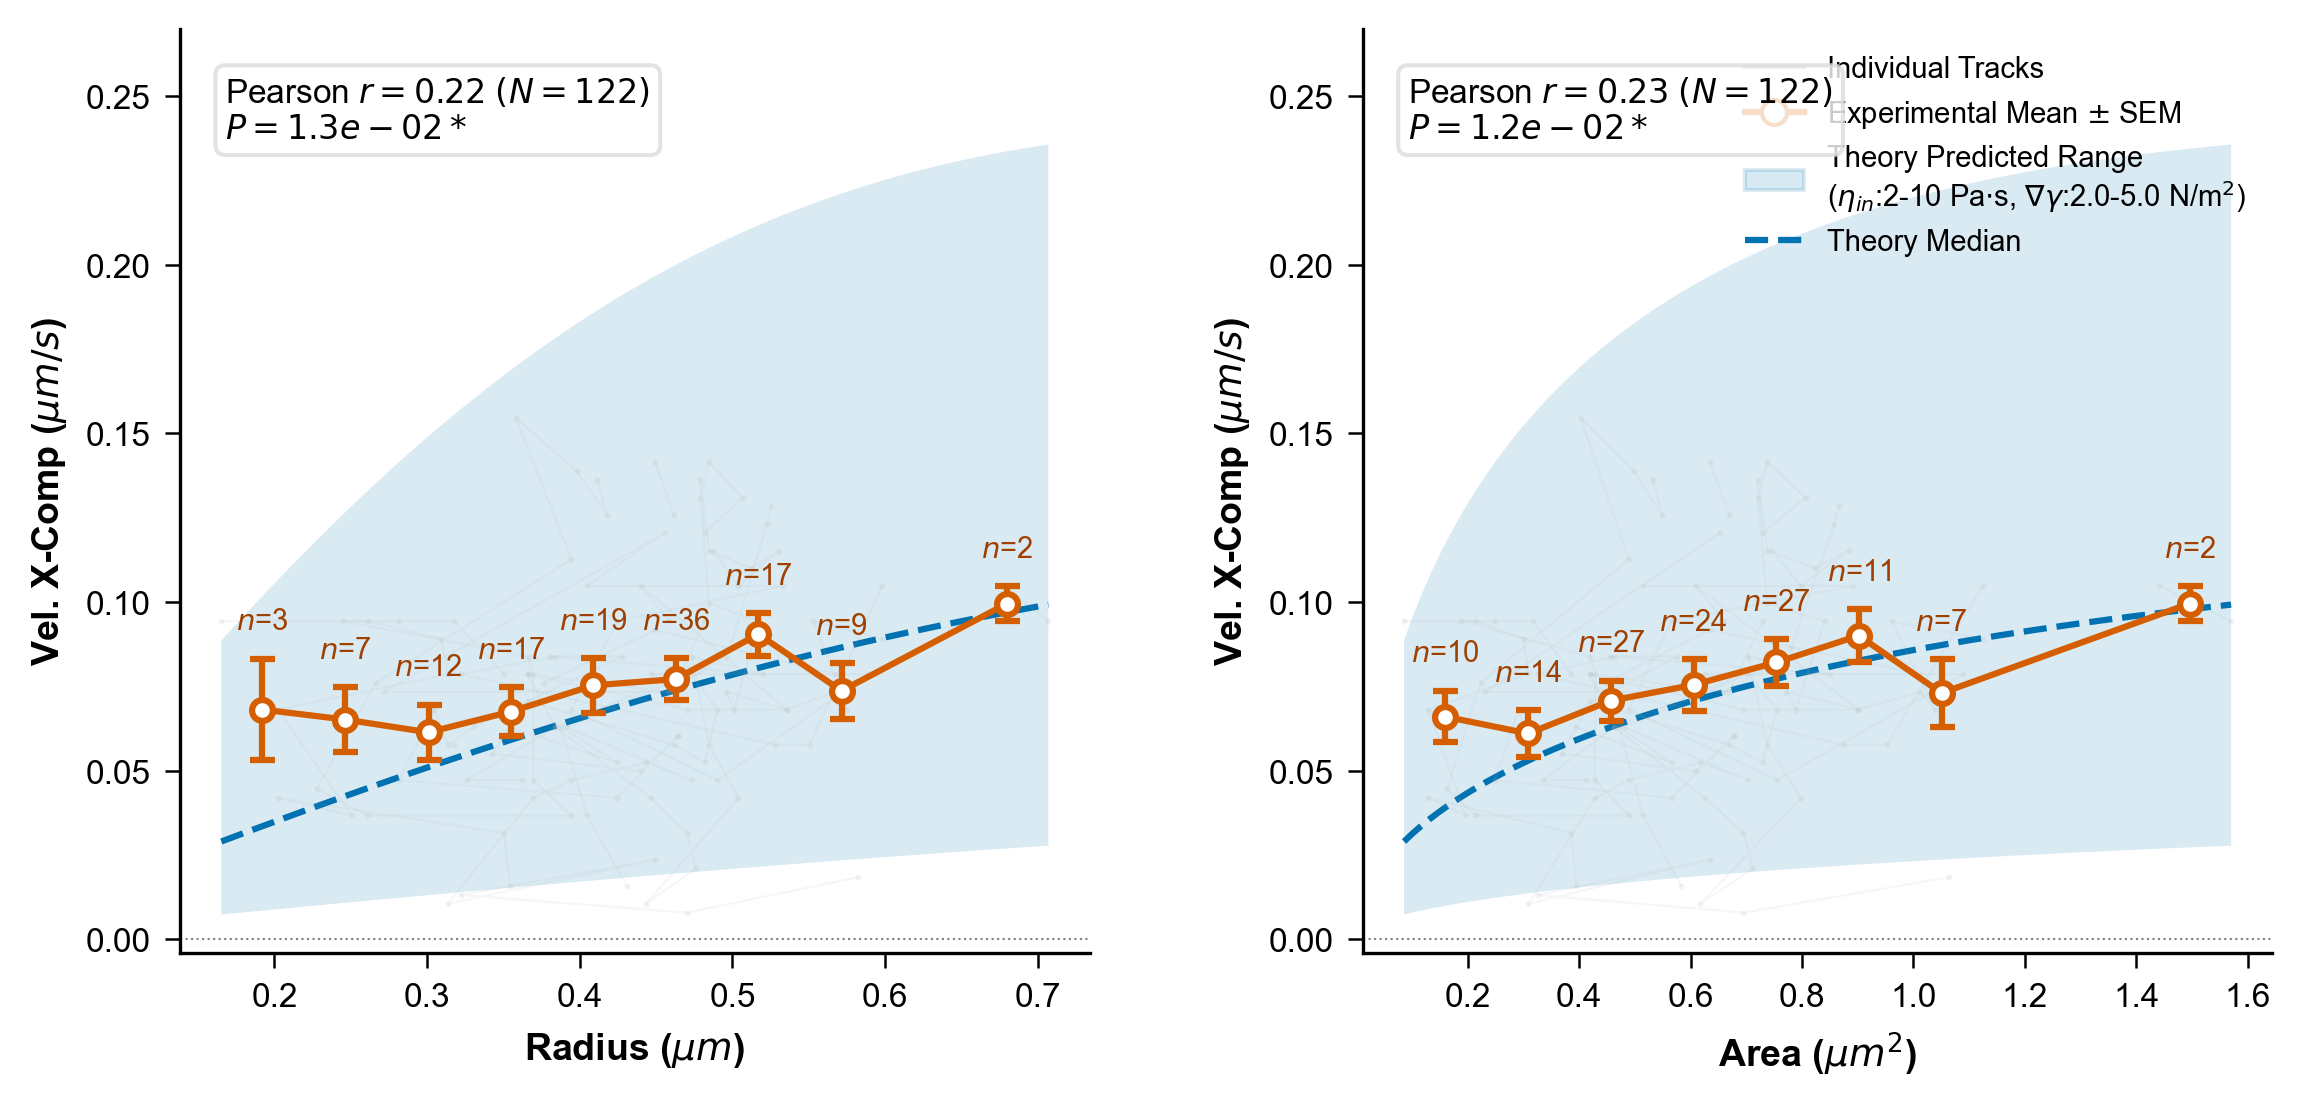

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import os

# ==========================================
# 0. Global Configuration (centralize all model/plotting/processing parameters)
# ==========================================
class Config:
    # --- Input/Output ---
    INPUT_FILE = 'D:\\Research\\Embryo_video\\260115_video.csv'
    SAVE_FILENAME = 'nature_style_velocity_X_analysis_ygb.svg'

    # --- Data Processing ---
    SMOOTH_WINDOW = 5
    BIN_COUNT = 10

    # --- YGB Theoretical Model Parameters ---
    XI_NM = 50               # Pore permeability coefficient (nm)
    ETA_SOL = 0.01           # Base solvent viscosity (Pa*s)

    # Theoretical band parameter range (upper/lower bounds for fill_between)
    THEORY_ETA_IN_MIN = 2
    THEORY_ETA_IN_MAX = 10
    THEORY_GRAD_GAMMA_MIN = 2.0
    THEORY_GRAD_GAMMA_MAX = 5.0

    # Theoretical centerline parameters
    THEORY_ETA_IN_MID = 5
    THEORY_GRAD_GAMMA_MID = 4.0

    # "True" parameters used for simulated-data generation
    SIM_ETA_IN = 3.0
    SIM_GRAD_GAMMA = 4.0
    SIM_NOISE_FRACTION = 0.15

    # --- Simulation Data Settings ---
    SIM_SEED = 123
    SIM_N_TRACKS = 18
    SIM_TIME_START, SIM_TIME_STOP, SIM_TIME_STEP = 0, 30, 0.5
    SIM_DIAMETER_MIN, SIM_DIAMETER_MAX = 1.5, 4.5
    SIM_DIAMETER_NOISE_STD = 0.05

    # --- Nature Plotting Style ---
    FONT_FAMILY = 'sans-serif'
    FONT_LIST = ['Arial', 'Helvetica', 'DejaVu Sans']
    FONT_SIZE = 8
    AXES_LABEL_SIZE = 9
    TICK_LABEL_SIZE = 8
    AXES_LINE_WIDTH = 0.8
    TICK_MAJOR_WIDTH = 0.6
    FIGURE_DPI = 300

    # --- Color Scheme ---
    COLOR_RAW = '#B0B0B0'      # Light gray (trajectories)
    COLOR_STAT = '#D55E00'     # Vermilion (experimental statistics)
    COLOR_TEXT = '#A04000'     # Dark vermilion (text)
    COLOR_THEORY = '#0072B2'   # Scientific blue (theoretical prediction region)

    # --- Figure Settings ---
    FIG_WIDTH = 9
    FIG_HEIGHT = 4
    WSPACE = 0.3


# ==========================================
# 1. Plotting Style Settings (read from Config)
# ==========================================
def set_nature_style():
    plt.rcParams['font.family'] = Config.FONT_FAMILY
    plt.rcParams['font.sans-serif'] = Config.FONT_LIST
    plt.rcParams['font.size'] = Config.FONT_SIZE
    plt.rcParams['axes.labelsize'] = Config.AXES_LABEL_SIZE
    plt.rcParams['xtick.labelsize'] = Config.TICK_LABEL_SIZE
    plt.rcParams['ytick.labelsize'] = Config.TICK_LABEL_SIZE
    plt.rcParams['axes.linewidth'] = Config.AXES_LINE_WIDTH
    plt.rcParams['xtick.major.width'] = Config.TICK_MAJOR_WIDTH
    plt.rcParams['ytick.major.width'] = Config.TICK_MAJOR_WIDTH
    plt.rcParams['figure.dpi'] = Config.FIGURE_DPI
    plt.rcParams['savefig.bbox'] = 'tight'

# ==========================================
# 2. Theoretical Model: YGB Relationship (Marangoni Effect)
# ==========================================
def calculate_ygb_velocity(r_um, eta_in, grad_gamma, xi_nm=None, eta_sol=None):
    """
    计算基于 Young-Goldstein-Block (YGB) 关系的 Marangoni 迁移速度。
    公式: U_Ma = (2R) / (3 * (2*eta_out_eff + 3*eta_in)) * grad_gamma
    """
    if xi_nm is None: xi_nm = Config.XI_NM
    if eta_sol is None: eta_sol = Config.ETA_SOL

    r_m = r_um * 1e-6
    xi_m = xi_nm * 1e-9

    eta_out_eff = eta_sol * (r_m / xi_m)**2

    numerator = 2 * r_m * grad_gamma
    denominator = 3 * (2 * eta_out_eff + 3 * eta_in)
    u_ms = numerator / denominator

    return u_ms * 1e6

# ==========================================
# 3. Data Processing: smoothing and binning
# ==========================================
def process_data_robust(df, smooth_window=None):
    if smooth_window is None: smooth_window = Config.SMOOTH_WINDOW

    processed_rows = []
    grouped = df.groupby('TRACK_ID')

    for track_id, group in grouped:
        g = group.sort_values('POSITION_T').reset_index(drop=True)

        d_pos_x = g['POSITION_X'].diff()
        dt = g['POSITION_T'].diff()
        v_x = d_pos_x / dt

        if smooth_window > 1:
            v_x = v_x.rolling(window=smooth_window, center=True).mean()

        temp_df = pd.DataFrame({
            'TRACK_ID': track_id,
            'Time': g['POSITION_T'],
            'Radius': g['DIAMETER'] / 2.0,
            'Area': g['AREA'],
            'Velocity_X': v_x
        })

        temp_df = temp_df.dropna()
        processed_rows.append(temp_df)

    return pd.concat(processed_rows)

def calculate_binned_stats(df, x_col, y_col, bins=None):
    if bins is None: bins = Config.BIN_COUNT

    df['bin'] = pd.cut(df[x_col], bins=bins)
    stats = df.groupby('bin', observed=True)[y_col].agg(['mean', 'sem', 'count']).reset_index()
    stats['x_center'] = stats['bin'].apply(lambda x: x.mid).astype(float)
    return stats.dropna()

# ==========================================
# 4. Simulated Data Generation (using the YGB theory as the underlying physical mechanism)
# ==========================================
def generate_noisy_data():
    np.random.seed(Config.SIM_SEED)
    data = []

    t = np.arange(Config.SIM_TIME_START, Config.SIM_TIME_STOP, Config.SIM_TIME_STEP)

    for tid in range(1, Config.SIM_N_TRACKS + 1):
        base_dia = np.random.uniform(Config.SIM_DIAMETER_MIN, Config.SIM_DIAMETER_MAX)
        dia = base_dia + np.random.normal(0, Config.SIM_DIAMETER_NOISE_STD, len(t))
        area = np.pi * (dia / 2)**2

        true_v = calculate_ygb_velocity(dia / 2, eta_in=Config.SIM_ETA_IN, grad_gamma=Config.SIM_GRAD_GAMMA)
        noise = np.random.normal(0, true_v.mean() * Config.SIM_NOISE_FRACTION, len(t))

        v_inst = true_v + noise
        x = np.cumsum(v_inst * Config.SIM_TIME_STEP)
        y = np.random.normal(0, 1, len(t))

        for i in range(len(t)):
            data.append([tid, t[i], x[i], y[i], dia[i], area[i]])

    return pd.DataFrame(data, columns=['TRACK_ID', 'POSITION_T', 'POSITION_X', 'POSITION_Y', 'DIAMETER', 'AREA'])

# ==========================================
# 5. Core Plotting: combine experimental data with the theoretical model
# ==========================================
def plot_hybrid_analysis(df, save_dir='.'):
    set_nature_style()

    # === Overall Dataset Statistics ===
    mean_v = df['Velocity_X'].mean()
    sd_v = df['Velocity_X'].std()
    mean_r = df['Radius'].mean()
    sd_r = df['Radius'].std()

    v_theory_min = calculate_ygb_velocity(mean_r, eta_in=Config.THEORY_ETA_IN_MAX, grad_gamma=Config.THEORY_GRAD_GAMMA_MIN)
    v_theory_max = calculate_ygb_velocity(mean_r, eta_in=Config.THEORY_ETA_IN_MIN, grad_gamma=Config.THEORY_GRAD_GAMMA_MAX)

    print("=" * 65)
    print("Overall Dataset Statistics (Unbinned):")
    print(f"Velocity_X (v) : {mean_v:.4f} ± {sd_v:.4f} μm/s")
    print(f"Radius (R)     : {mean_r:.4f} ± {sd_r:.4f} μm")
    print(f"Theory V Range at Mean R: {v_theory_min:.4f} ~ {v_theory_max:.4f} μm/s")
    print("Total Data Pts : N =", len(df))
    print("=" * 65)

    fig, axes = plt.subplots(1, 2, figsize=(Config.FIG_WIDTH, Config.FIG_HEIGHT))
    plt.subplots_adjust(wspace=Config.WSPACE)

    configs = [
        {'x': 'Radius', 'y': 'Velocity_X', 'ax': axes[0],
         'xlab': 'Radius ($\mu m$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'},
        {'x': 'Area', 'y': 'Velocity_X', 'ax': axes[1],
         'xlab': 'Area ($\mu m^2$)', 'ylab': 'Vel. X-Comp ($\mu m/s$)'}
    ]

    print(f"{'X Variable':<15} | {'Y Variable':<15} | {'Pearson r':<10} | {'P-value':<10} | {'N(Total)'}")
    print("-" * 65)

    for cfg in configs:
        ax = cfg['ax']
        x_col = cfg['x']
        y_col = cfg['y']

        # === 1. Theoretical Trend Band ===
        x_min, x_max = df[x_col].min(), df[x_col].max()
        x_vals_smooth = np.linspace(x_min, x_max, 100)

        if x_col == 'Radius':
            r_vals = x_vals_smooth
        else:
            r_vals = np.sqrt(x_vals_smooth / np.pi)

        u_max = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MIN, grad_gamma=Config.THEORY_GRAD_GAMMA_MAX)
        u_min = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MAX, grad_gamma=Config.THEORY_GRAD_GAMMA_MIN)
        u_mid = calculate_ygb_velocity(r_vals, eta_in=Config.THEORY_ETA_IN_MID, grad_gamma=Config.THEORY_GRAD_GAMMA_MID)

        ax.fill_between(x_vals_smooth, u_min, u_max, color=Config.COLOR_THEORY, alpha=0.15, zorder=2, edgecolor='none')
        ax.plot(x_vals_smooth, u_mid, color=Config.COLOR_THEORY, linestyle='--', linewidth=1.5, zorder=3)

        # === 2. Raw Experimental Data ===
        clean_data = df[[x_col, y_col]].dropna()
        n_total = len(clean_data)
        r, p = pearsonr(clean_data[x_col], clean_data[y_col])
        print(f"{x_col:<15} | {y_col:<15} | {r:.4f}     | {p:.4e} | {n_total}")

        stars = ''
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'

        stats_text = f"Pearson $r = {r:.2f}$ $(N={n_total})$\n$P = {p:.1e}{stars}$"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                verticalalignment='top', fontsize=Config.FONT_SIZE,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#dddddd'),
                zorder=20)

        for tid in df['TRACK_ID'].unique():
            sub = df[df['TRACK_ID'] == tid]
            sub_by_time = sub.sort_values('Time')
            ax.plot(sub_by_time[x_col], sub_by_time[y_col],
                    color=Config.COLOR_RAW, alpha=0.1, linewidth=0.5, linestyle='-', zorder=4)
            ax.scatter(sub[x_col], sub[y_col], color=Config.COLOR_RAW, s=2, alpha=0.15, linewidth=0, zorder=4)

        # === 3. Binned Statistics ===
        stats = calculate_binned_stats(df, x_col, y_col, bins=Config.BIN_COUNT)

        ax.errorbar(stats['x_center'], stats['mean'], yerr=stats['sem'],
                    fmt='-o', color=Config.COLOR_STAT, linewidth=1.5, capsize=3, markersize=5,
                    markerfacecolor='white', markeredgewidth=1.5, zorder=10)

        y_span = max(df[y_col].max(), u_max.max()) - min(df[y_col].min(), u_min.min())
        offset = y_span * 0.03

        for _, row in stats.iterrows():
            text_y = row['mean'] + (row['sem'] if not np.isnan(row['sem']) else 0) + offset
            ax.text(row['x_center'], text_y, f"$n$={int(row['count'])}",
                    ha='center', va='bottom', fontsize=7, color=Config.COLOR_TEXT, zorder=15)

        # === 4. Decorations ===
        ax.set_xlabel(cfg['xlab'], fontweight='bold')
        ax.set_ylabel(cfg['ylab'], fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] + y_span * 0.1)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.5, zorder=0)

    # Legend
    legend_elements = [
        Line2D([0], [0], color=Config.COLOR_RAW, lw=1, label='Individual Tracks'),
        Line2D([0], [0], color=Config.COLOR_STAT, lw=1.5, marker='o', markerfacecolor='white', label='Experimental Mean $\pm$ SEM'),
        mpatches.Patch(color=Config.COLOR_THEORY, alpha=0.15, label=f'Theory Predicted Range\n($\eta_{{in}}$:{Config.THEORY_ETA_IN_MIN}-{Config.THEORY_ETA_IN_MAX} Pa$\cdot$s, $\\nabla\\gamma$:{Config.THEORY_GRAD_GAMMA_MIN}-{Config.THEORY_GRAD_GAMMA_MAX} N/m$^2$)'),
        Line2D([0], [0], color=Config.COLOR_THEORY, lw=1.5, linestyle='--', label='Theory Median')
    ]
    axes[1].legend(handles=legend_elements, frameon=False, loc='upper right', fontsize=7)

    save_path = os.path.join(save_dir, Config.SAVE_FILENAME)
    plt.savefig(save_path, format='svg')
    print("-" * 65)
    print(f"Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    input_file = Config.INPUT_FILE

    file_dir = os.path.dirname(input_file)
    if not file_dir: file_dir = '.'

    if os.path.exists(input_file):
        print(f"Loading data from {input_file}...")
        raw = pd.read_csv(input_file)

        processed = process_data_robust(raw)
        plot_hybrid_analysis(processed, save_dir=file_dir)

    else:
        print(f"Warning: File {input_file} not found. Using generated mock data.")
        raw = generate_noisy_data()
        processed = process_data_robust(raw)
        plot_hybrid_analysis(processed, save_dir='.')